In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

In [ ]:
np.random.seed(42)
n_samples= 300

age=np.random.randint(30, 80, size=n_samples)
chol= np.random.randint(150, 300, size=n_samples)
thalach= np.random.randint(90, 200, size=n_samples)

# we create a simple ruule-based probability for disease just for realism
risk_score= 0.03 * (age-40) + 0.02 * (chol-200) - 0.02 * (thalach-120)
prob= 1/ (1+np.exp(-0.05 * risk_score))

target= (prob > np.median(prob)).astype(int)

df= pd.DataFrame({
    "age": age,
    "chol": chol,
    "thalach": thalach,
    "target": target
})

df

,age,chol,thalach,target
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0
...,...,...,...,...
295,62,207,188,0
296,53,297,104,1
297,40,210,153,0
298,78,276,178,1


In [ ]:
X= df[["age", "chol", "thalach"]]
y=df["target"]

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

model= DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# confusion matrix
y_pred= model.predict(X_test)

cm= confusion_matrix(y_test, y_pred)
print(cm)

[[23  3]
 [ 6 28]]


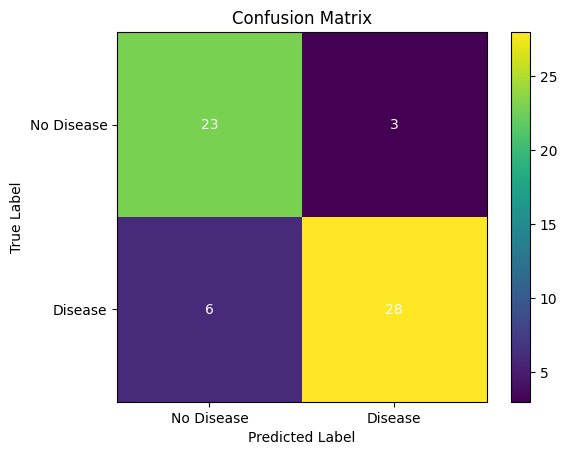

In [ ]:
# plot of confusio matrix
fig, ax =plt.subplots()
im= ax.imshow(cm, interpolation= "nearest")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

# show all ticks and label them
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["No Disease", "Disease"])
ax.set_yticklabels(["No Disease", "Disease"])

# loop voer data dimensions and create text annotations
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j, i, cm[i, j], ha="center", va="center", color="white")

plt.colorbar(im)
plt.show()

In [ ]:
# accuracy, precision, racall , f1 score

acc= accuracy_score(y_test, y_pred)
prec= precision_score(y_test, y_pred)
rec= recall_score(y_test, y_pred)
f1= f1_score(y_test, y_pred)

print("Accuracy: ", round(acc, 3))
print("Precesion: ", round(prec, 3))
print("Recall: ", round(rec, 3))
print("F1: ", round(f1, 3))

Accuracy:  0.85
Precesion:  0.903
Recall:  0.824
F1:  0.862
